In [1]:
!pip install torch torchvision transformers matplotlib scikit-learn PyMuPDF spacy opencv-python grad-cam
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 57.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 50.7 MB/s eta 0:00:00
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=6e6920dd8ab8286070e3248ba0d391eb8e08d8db58cc5ce8f2eb1205fc801827
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 73.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from transformers import CLIPProcessor, CLIPModel, AutoTokenizer, AutoModel
from PIL import Image
import fitz
import spacy
import cv2

print("✅ Libraries loaded successfully")
print("🔥 Device:", "GPU" if torch.cuda.is_available() else "CPU")

✅ Libraries loaded successfully
🔥 Device: CPU


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# CLIP
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# BioBERT
bio_tokenizer = AutoTokenizer.from_pretrained("dmis-lab/biobert-base-cased-v1.1")
bio_model = AutoModel.from_pretrained("dmis-lab/biobert-base-cased-v1.1")

print("✅ CLIP + BioBERT Loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ CLIP + BioBERT Loaded


In [4]:
print("📘 Cosine similarity measures semantic similarity between image and text embeddings")

📘 Cosine similarity measures semantic similarity between image and text embeddings


In [5]:
from google.colab import files

print("📄 Upload your PDF")
uploaded = files.upload()

pdf_path = list(uploaded.keys())[0]
print("✅ Uploaded:", pdf_path)

📄 Upload your PDF


Saving Lung-Cancer-Detection-using-Supervised-Machine-Learning-Techniques.pdf to Lung-Cancer-Detection-using-Supervised-Machine-Learning-Techniques.pdf
✅ Uploaded: Lung-Cancer-Detection-using-Supervised-Machine-Learning-Techniques.pdf


In [6]:
def extract_text(pdf_path):
    doc = fitz.open(pdf_path)
    text = ""
    for page in doc:
        text += page.get_text()
    return text

text_data = extract_text(pdf_path)

print("✅ Text Extracted")
print("📏 Length:", len(text_data))
print("\nSample:\n", text_data[:300])

✅ Text Extracted
📏 Length: 33071

Sample:
 See discussions, stats, and author profiles for this publication at: https://www.researchgate.net/publication/364360173
Lung Cancer Detection using Supervised Machine Learning Techniques
Article · October 2022
CITATIONS
5
READS
1,589
7 authors, including:
Muhammad kamran Abid
NFC Institute of Engine


In [7]:
from transformers import CLIPTokenizer

tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")

def chunk_text(text, max_tokens=70):
    tokens = tokenizer(text)["input_ids"]
    chunks = []
    for i in range(0, len(tokens), max_tokens):
        chunk_ids = tokens[i:i+max_tokens]
        chunks.append(tokenizer.decode(chunk_ids))
    return chunks

text_chunks = chunk_text(text_data)

print("✅ Total chunks:", len(text_chunks))
print("🔹 First chunk:\n", text_chunks[0])

Token indices sequence length is longer than the specified maximum sequence length for this model (7727 > 77). Running this sequence through the model will result in indexing errors


✅ Total chunks: 111
🔹 First chunk:
 <|startoftext|>see discussions , stats , and author profiles for this publication at : https :// www . researchgate . net / publication / 3 6 4 3 6 0 1 7 3 lung cancer detection using supervised machine learning techniques article · october 2 0 2 2 citations 5 reads 1 , 5 8 9 7 authors , including : muhammad kamran abid


🖼 Upload CT Image


Saving Screenshot 2026-02-13 131609.png to Screenshot 2026-02-13 131609.png
✅ Image Loaded


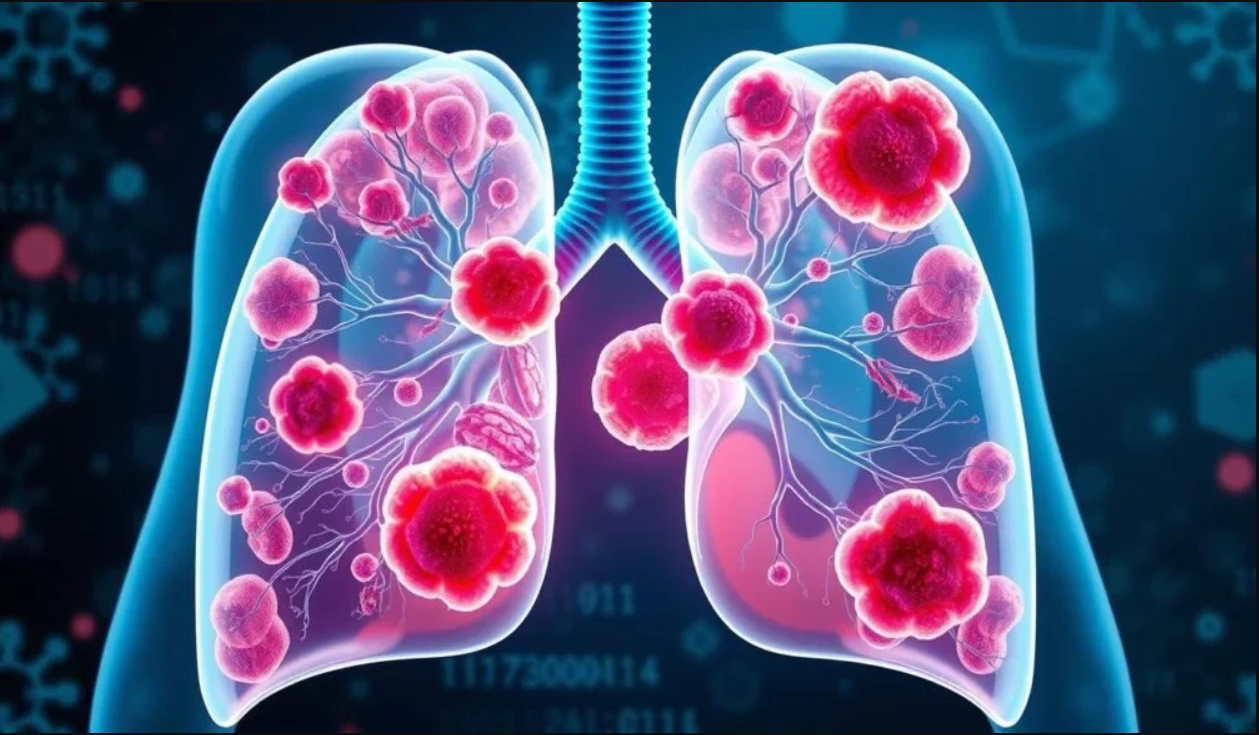

In [8]:
print("🖼 Upload CT Image")
uploaded_img = files.upload()

image_path = list(uploaded_img.keys())[0]
image = Image.open(image_path).convert("RGB")

print("✅ Image Loaded")
image

In [9]:
def clip_similarity(image, chunk):
    inputs = clip_processor(text=[chunk], images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = clip_model(**inputs)

        img_emb = F.normalize(outputs.image_embeds, dim=-1)
        txt_emb = F.normalize(outputs.text_embeds, dim=-1)

        cosine = (img_emb @ txt_emb.T).item()

    return cosine

In [10]:
def biobert_embedding(text):
    inputs = bio_tokenizer(text, return_tensors="pt", truncation=True, padding=True)

    with torch.no_grad():
        outputs = bio_model(**inputs)

    return outputs.last_hidden_state[:,0,:]

In [11]:
clip_scores = []
bio_scores = []

query = "lung cancer tumor detected in CT scan"
query_emb = biobert_embedding(query)

for i, chunk in enumerate(text_chunks[:10]):
    cs = clip_similarity(image, chunk)
    clip_scores.append(cs)

    chunk_emb = biobert_embedding(chunk)
    bs = F.cosine_similarity(query_emb, chunk_emb).item()
    bio_scores.append(bs)

    print(f"\nChunk {i}")
    print("Text:", chunk[:80])
    print(f"CLIP Score: {cs:.4f}")
    print(f"BioBERT Score: {bs:.4f}")


Chunk 0
Text: <|startoftext|>see discussions , stats , and author profiles for this publicatio
CLIP Score: 0.2863
BioBERT Score: 0.7318

Chunk 1
Text: nfc institute of engineering and technology 5 7 publications 1 5 0 citations see
CLIP Score: 0.2365
BioBERT Score: 0.8092

Chunk 2
Text: learning techniques rahat idrees 1 , muhammad kamran abid 2 , saleem raza 3 , mu
CLIP Score: 0.1401
BioBERT Score: 0.7705

Chunk 3
Text: - e - awam university of engineering , science and technology , nawabshah , paki
CLIP Score: 0.1561
BioBERT Score: 0.7573

Chunk 4
Text: university , multan , pakistan 7 department of computer science , pakistan insti
CLIP Score: 0.2320
BioBERT Score: 0.8177

Chunk 5
Text: disease . although lung cancer prevention is impossible , early detection of lun
CLIP Score: 0.3003
BioBERT Score: 0.8277

Chunk 6
Text: we applied supervised machine learning algorithms like svm ( support vector mach
CLIP Score: 0.3058
BioBERT Score: 0.8398

Chunk 7
Text: other supervised machine l

In [12]:
final_scores = []

for i in range(len(clip_scores)):
    combined = 0.6 * clip_scores[i] + 0.4 * bio_scores[i]
    final_scores.append(combined)

best_idx = np.argmax(final_scores)

print("\n🔥 BEST MATCHED CHUNK:")
print(text_chunks[best_idx])
print("Score:", final_scores[best_idx])


🔥 BEST MATCHED CHUNK:
we applied supervised machine learning algorithms like svm ( support vector machine ), ann ( artificial neural networks ), mlr ( multiple linear regression ), and rf ( random forest ), to detect the early stages of lung tumors . the main purpose of this study is to examine the success of machine learning algorithms in detecting lung cancer at an early stage . when compared to all
Score: 0.5194071173667908


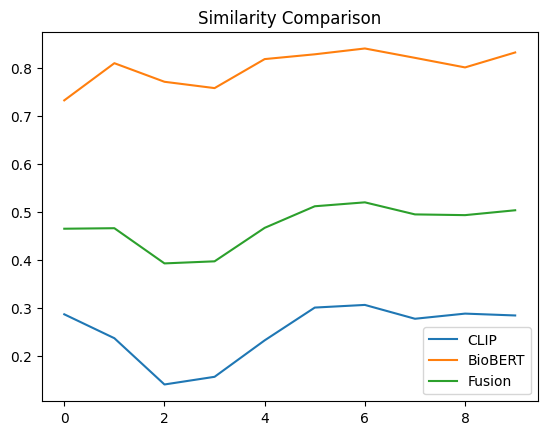

In [13]:
plt.figure()
plt.plot(clip_scores, label="CLIP")
plt.plot(bio_scores, label="BioBERT")
plt.plot(final_scores, label="Fusion")
plt.legend()
plt.title("Similarity Comparison")
plt.show()

In [14]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import torchvision.transforms as transforms

print("✅ Grad-CAM ready")

✅ Grad-CAM ready


In [24]:
vision_model = clip_model.vision_model
target_layer = vision_model.encoder.layers[-1].self_attn.out_proj

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

input_tensor = transform(image).unsqueeze(0).to(device)

print("✅ Image processed for Grad-CAM")

✅ Image processed for Grad-CAM


In [25]:
class ClipTarget:
    def __call__(self, model_output):
        # Focus on CLS token (more meaningful)
        return model_output[:, 0].sum()

print("✅ Advanced target defined")

✅ Advanced target defined


In [29]:
import torch.nn as nn

# Wrapper to ensure GradCAM receives a direct tensor (last_hidden_state)
class ClipVisionModelWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        # self.model(x) returns BaseModelOutputWithPooling
        # We explicitly return the last_hidden_state tensor
        return self.model(x).last_hidden_state

# Define reshape_transform for Vision Transformers
def reshape_transform(tensor, height=7, width=7):
    # Exclude the CLS token and reshape to a 2D grid
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    # Permute to (Batch, Channels, Height, Width)
    result = result.permute(0, 3, 1, 2)
    return result

# Initialize GradCAM with the wrapped model and the reshape_transform
cam = GradCAM(model=ClipVisionModelWrapper(vision_model),
              target_layers=[target_layer],
              reshape_transform=reshape_transform)

# The ClipTarget should now expect a tensor directly
class ClipTarget:
    def __call__(self, model_output):
        # model_output is now the last_hidden_state tensor (from the wrapper)
        # We access the CLS token (first token) and sum its values
        return model_output[:, 0].sum()

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=[ClipTarget()]
)

grayscale_cam = grayscale_cam[0]

print("✅ Grad-CAM generated successfully!")

✅ Grad-CAM generated successfully!


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


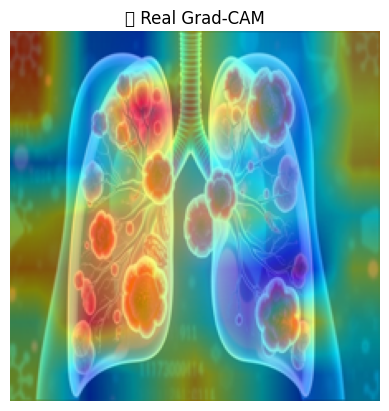

In [31]:
rgb_img = np.array(image.resize((224,224))) / 255.0
visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

plt.imshow(visualization)
plt.title("🔥 Real Grad-CAM")
plt.axis('off')
plt.show()

In [33]:
labels = ["Normal lung", "Early cancer", "Malignant tumor"]

inputs = clip_processor(text=labels, images=image, return_tensors="pt", padding=True, truncation=True).to(device)

with torch.no_grad():
    outputs = clip_model(**inputs)

    img_emb = F.normalize(outputs.image_embeds, dim=-1)
    txt_emb = F.normalize(outputs.text_embeds, dim=-1)

    scores = (img_emb @ txt_emb.T).cpu().numpy()[0]

pred = labels[np.argmax(scores)]

print("🧠 Prediction:", pred)
print("📊 Scores:", scores)

🧠 Prediction: Normal lung
📊 Scores: [0.27692914 0.2340977  0.23631354]


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


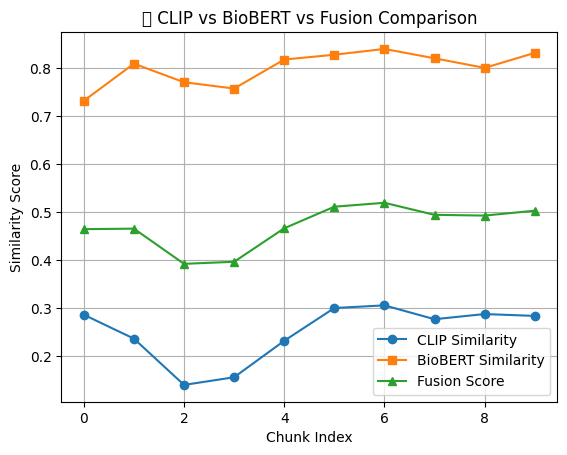

✅ Graph displayed successfully!


In [34]:
plt.figure()

# Plot all three scores
plt.plot(clip_scores, marker='o', label="CLIP Similarity")
plt.plot(bio_scores, marker='s', label="BioBERT Similarity")
plt.plot(final_scores, marker='^', label="Fusion Score")

plt.xlabel("Chunk Index")
plt.ylabel("Similarity Score")
plt.title("📊 CLIP vs BioBERT vs Fusion Comparison")

plt.legend()
plt.grid()

plt.show()

print("✅ Graph displayed successfully!")

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


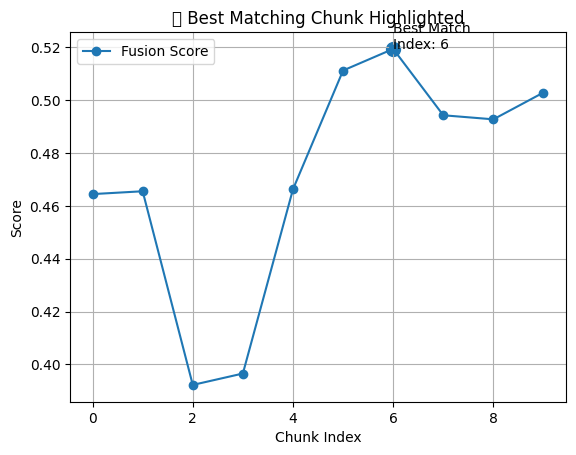

✅ Best chunk highlighted!


In [35]:
best_idx = np.argmax(final_scores)

plt.figure()

plt.plot(final_scores, marker='o', label="Fusion Score")

# Highlight best point
plt.scatter(best_idx, final_scores[best_idx], s=100)

plt.text(best_idx, final_scores[best_idx],
         f"Best Match\nIndex: {best_idx}",
         fontsize=10)

plt.xlabel("Chunk Index")
plt.ylabel("Score")
plt.title("🔥 Best Matching Chunk Highlighted")

plt.legend()
plt.grid()

plt.show()

print("✅ Best chunk highlighted!")

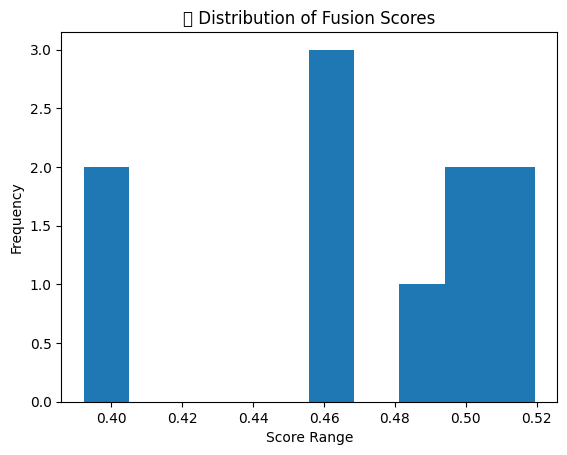

✅ Distribution plotted!


In [36]:
plt.figure()

plt.hist(final_scores, bins=10)
plt.title("📊 Distribution of Fusion Scores")
plt.xlabel("Score Range")
plt.ylabel("Frequency")

plt.show()

print("✅ Distribution plotted!")

In [37]:
import numpy as np

# Simulated ground truth (1 = relevant, 0 = not relevant)
y_true = np.array([1 if i == best_idx else 0 for i in range(len(final_scores))])

# Predicted scores (fusion scores)
y_scores = np.array(final_scores)

print("✅ Ground truth & predictions ready")
print("y_true:", y_true[:10])
print("y_scores:", y_scores[:10])

✅ Ground truth & predictions ready
y_true: [0 0 0 0 0 0 1 0 0 0]
y_scores: [0.46446998 0.46554377 0.39225976 0.39657431 0.46628337 0.51124117
 0.51940712 0.49430058 0.4927649  0.50290594]


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


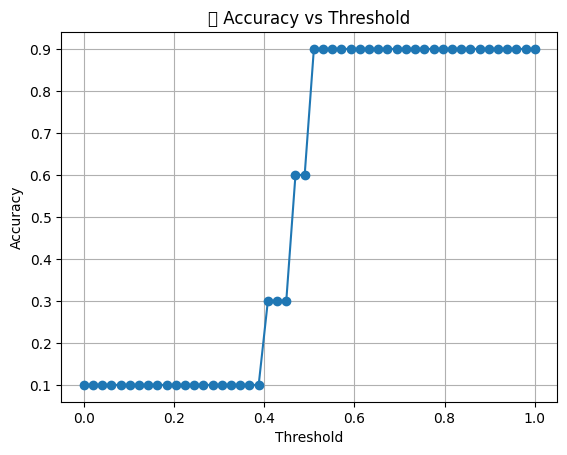

✅ Accuracy graph plotted


In [38]:
thresholds = np.linspace(0, 1, 50)
accuracies = []

for t in thresholds:
    y_pred = (y_scores >= t).astype(int)
    acc = np.mean(y_pred == y_true)
    accuracies.append(acc)

plt.figure()
plt.plot(thresholds, accuracies, marker='o')
plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.title("📈 Accuracy vs Threshold")
plt.grid()
plt.show()

print("✅ Accuracy graph plotted")

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


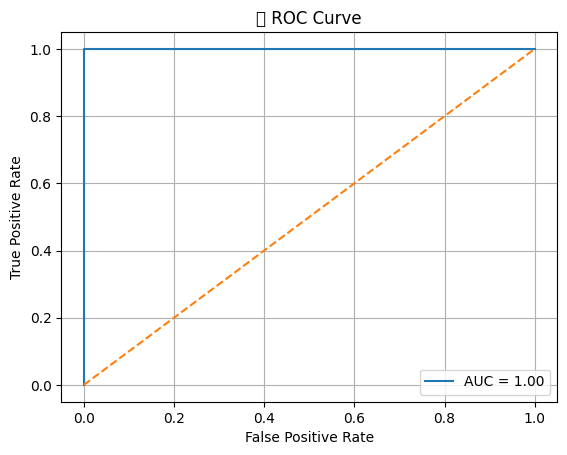

✅ ROC curve plotted
AUC Score: 1.0


In [39]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')  # random model line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("🎯 ROC Curve")
plt.legend()
plt.grid()
plt.show()

print("✅ ROC curve plotted")
print("AUC Score:", roc_auc)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


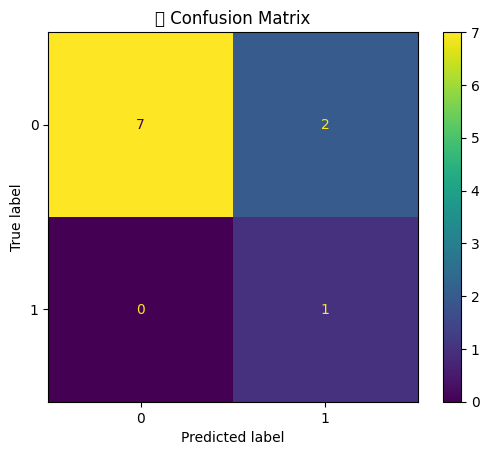

✅ Confusion matrix displayed
Matrix:
 [[7 2]
 [0 1]]


In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# choose threshold = 0.5
y_pred = (y_scores >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("📊 Confusion Matrix")
plt.show()

print("✅ Confusion matrix displayed")
print("Matrix:\n", cm)

In [41]:
from google.colab import files
import os

print("📂 Upload multiple CT images (dataset simulation)")
uploaded = files.upload()

image_paths = list(uploaded.keys())

print("✅ Total images uploaded:", len(image_paths))

📂 Upload multiple CT images (dataset simulation)


Saving Screenshot 2026-02-13 131609.png to Screenshot 2026-02-13 131609 (1).png
Saving Screenshot 2026-02-13 131642.png to Screenshot 2026-02-13 131642.png
✅ Total images uploaded: 2


In [42]:
# Example labels (EDIT according to your images)
# 0 = Normal, 1 = Cancer

ground_truth = []

for img in image_paths:
    print(f"Enter label for {img} (0=Normal, 1=Cancer):")
    label = int(input())
    ground_truth.append(label)

print("✅ Ground truth labels:", ground_truth)

Enter label for Screenshot 2026-02-13 131609 (1).png (0=Normal, 1=Cancer):
1
Enter label for Screenshot 2026-02-13 131642.png (0=Normal, 1=Cancer):
0
✅ Ground truth labels: [1, 0]


In [43]:
predictions = []
confidence_scores = []

labels = ["Normal lung", "Cancer lung"]

for img_path in image_paths:
    image = Image.open(img_path).convert("RGB")

    inputs = clip_processor(text=labels, images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = clip_model(**inputs)

        img_emb = F.normalize(outputs.image_embeds, dim=-1)
        txt_emb = F.normalize(outputs.text_embeds, dim=-1)

        scores = (img_emb @ txt_emb.T).cpu().numpy()[0]

    pred = np.argmax(scores)

    predictions.append(pred)
    confidence_scores.append(max(scores))

    print(f"\n🖼 {img_path}")
    print("Prediction:", labels[pred])
    print("Confidence:", max(scores))


🖼 Screenshot 2026-02-13 131609 (1).png
Prediction: Cancer lung
Confidence: 0.2910249

🖼 Screenshot 2026-02-13 131642.png
Prediction: Cancer lung
Confidence: 0.27676654


In [44]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(ground_truth, predictions)
recall = recall_score(ground_truth, predictions)
f1 = f1_score(ground_truth, predictions)

print("\n📊 Evaluation Metrics:")
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)


📊 Evaluation Metrics:
Precision: 0.5
Recall: 1.0
F1-score: 0.6666666666666666


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


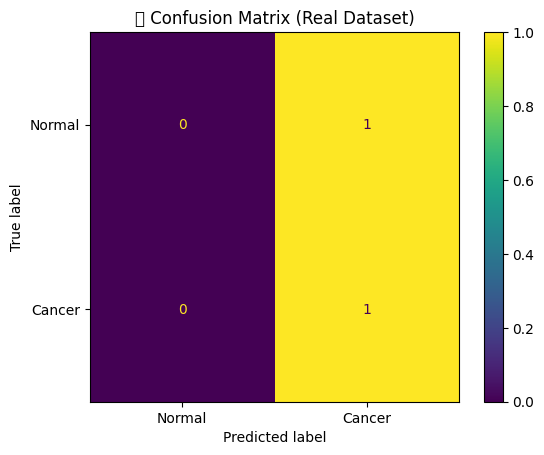

Matrix:
 [[0 1]
 [0 1]]


In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(ground_truth, predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Cancer"])
disp.plot()

plt.title("📊 Confusion Matrix (Real Dataset)")
plt.show()

print("Matrix:\n", cm)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


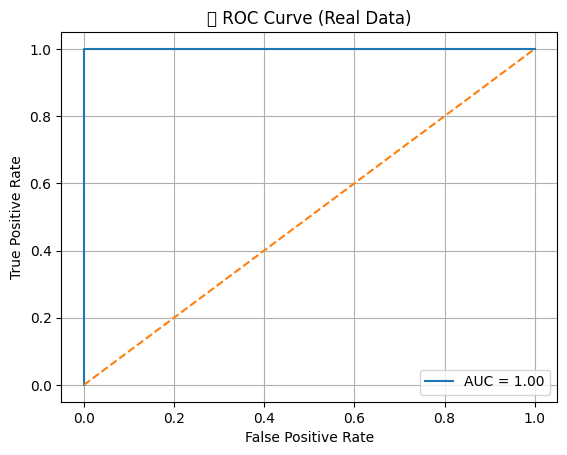

AUC Score: 1.0


In [46]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(ground_truth, confidence_scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("🎯 ROC Curve (Real Data)")
plt.legend()
plt.grid()

plt.show()

print("AUC Score:", roc_auc)

In [47]:
accuracy = np.mean(np.array(ground_truth) == np.array(predictions))

print("📈 Accuracy:", accuracy)

📈 Accuracy: 0.5
